Setup

Milestone 2: Visual Exploration and Flight Delay Trend Analysis

Dataset Description

The airline dataset contains information about flight departures, airports, routes, and flight status. It includes details such as departure date, time, route, month, and delay status. This dataset is used to analyze flight distribution patterns and identify delay trends using different visualizations.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

VISUAL EXPLORATION

In [16]:
file_path = "../data/raw/Airline_Dataset_Updated_Final.xlsx"

import pandas as pd

df = pd.read_excel(file_path)

print("Dataset Loaded Successfully ✅")
print("Shape:", df.shape)
df.head()

Dataset Loaded Successfully ✅
Shape: (98619, 22)


,Age,Airport Continent,Airport Country Code,Airport Name,Arrival Airport,Continents,Country Name,Departure Date,First Name,Flight Status,...,Nationality,Passenger ID,Pilot Name,Day of Departure,Time of Departure,Year,Month,Route,IsDelayed,IsCancelled
0,62,NAM,US,Coldfoot Airport,CXF,North America,United States,2022-06-28,Edithe,On Time,...,Japan,ABVWIg,Fransisco Hazeldine,Tuesday,18:46,2022.0,June,Coldfoot Airport - CXF,0,0
1,62,NAM,CA,Kugluktuk Airport,YCO,North America,Canada,2022-12-26,Elwood,On Time,...,Nicaragua,jkXXAX,Marla Parsonage,Monday,14:20,2022.0,December,Kugluktuk Airport - YCO,0,0
2,67,EU,FR,Grenoble-Isère Airport,GNB,Europe,France,2022-01-18,Darby,On Time,...,Russia,CdUz2g,Rhonda Amber,Tuesday,21:34,2022.0,January,Grenoble-Isère Airport - GNB,0,0
3,71,NAM,CA,Ottawa / Gatineau Airport,YND,North America,Canada,2022-09-16,Dominica,Delayed,...,China,BRS38V,Kacie Commucci,Friday,18:50,2022.0,September,Ottawa / Gatineau Airport - YND,1,0
4,21,NAM,US,Gillespie Field,SEE,North America,United States,2022-02-25,Bay,On Time,...,China,9kvTLo,Ebonee Tree,Friday,18:15,2022.0,February,Gillespie Field - SEE,0,0


Flights per Month

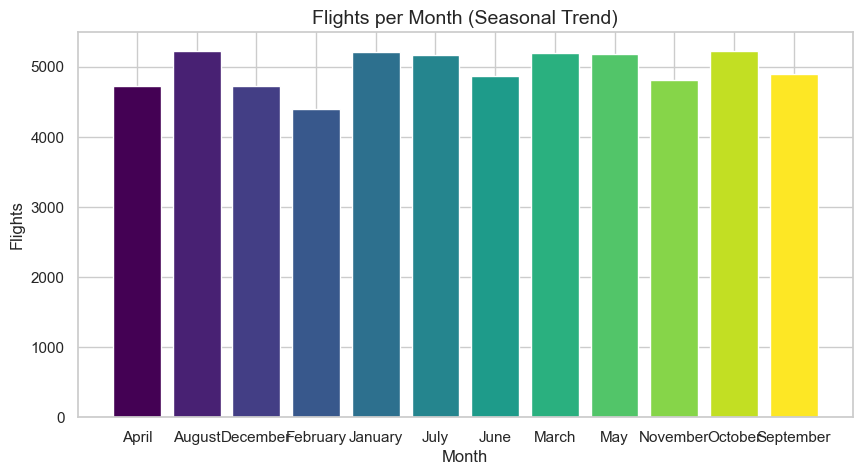

In [30]:
monthly = df['Month'].value_counts().sort_index()

plt.figure(figsize=(10,5))
colors = plt.cm.viridis(np.linspace(0,1,len(monthly)))

plt.bar(monthly.index, monthly.values, color=colors)

plt.title("Flights per Month (Seasonal Trend)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Flights")
plt.show()

Flights by Day of Week

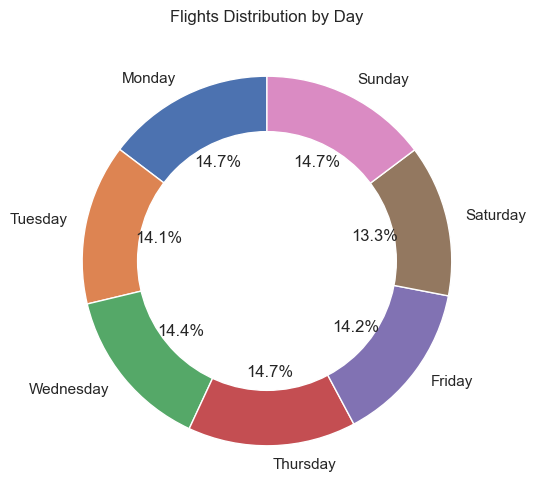

In [29]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['Day of Departure'].value_counts().reindex(order)

plt.figure(figsize=(6,6))
plt.pie(day_counts, labels=day_counts.index, autopct='%1.1f%%', startangle=90)

centre_circle = plt.Circle((0,0),0.70,fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Flights Distribution by Day")
plt.show()

Departure Time Distribution

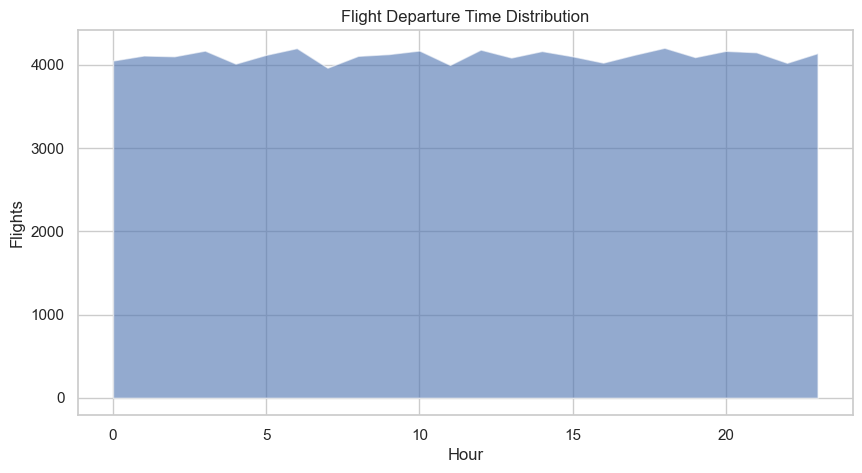

In [31]:
hour_counts = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.fill_between(hour_counts.index, hour_counts.values, alpha=0.6)

plt.title("Flight Departure Time Distribution")
plt.xlabel("Hour")
plt.ylabel("Flights")
plt.show()

Flight Status Distribution

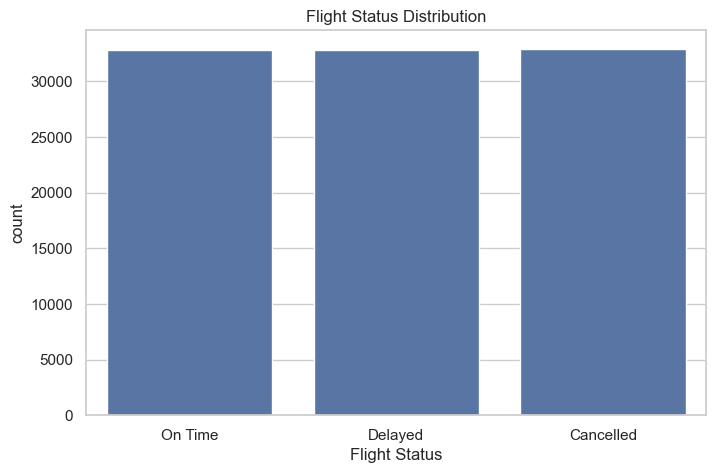

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x='Flight Status', data=df)

plt.title("Flight Status Distribution")
plt.show()

In [18]:
print(df.columns)

Index(['Age', 'Airport Continent', 'Airport Country Code', 'Airport Name',
       'Arrival Airport', 'Continents', 'Country Name', 'Departure Date',
       'First Name', 'Flight Status', 'Gender', 'Last Name', 'Nationality',
       'Passenger ID', 'Pilot Name', 'Day of Departure', 'Time of Departure',
       'Year', 'Month', 'Route', 'IsDelayed', 'IsCancelled'],
      dtype='object')


Delayed vs On-Time

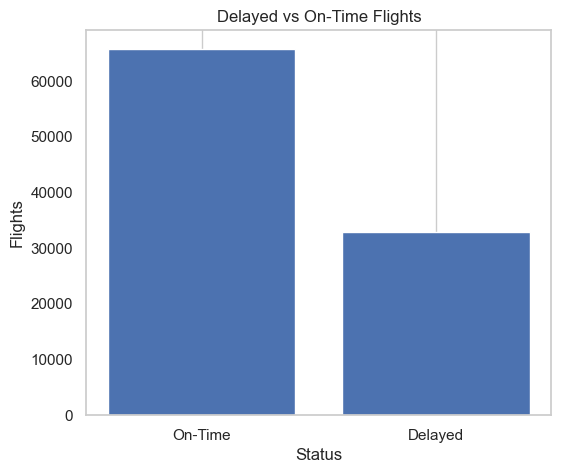

In [24]:
delay_counts = df['IsDelayed'].value_counts()

labels = ['On-Time', 'Delayed']

plt.figure(figsize=(6,5))
plt.bar(labels, delay_counts.values)

plt.title("Delayed vs On-Time Flights")
plt.xlabel("Status")
plt.ylabel("Flights")
plt.grid(axis='y')
plt.show()

Monthly Delay Trend

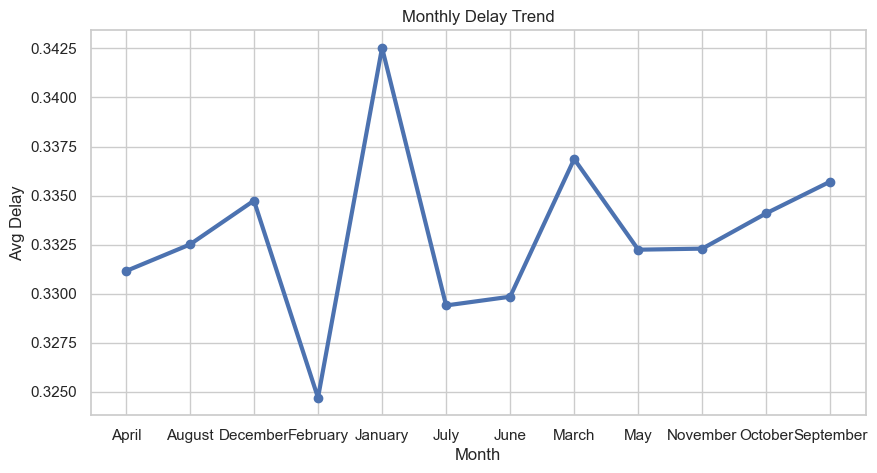

In [33]:
monthly_delay = df.groupby('Month')['IsDelayed'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_delay.index, monthly_delay.values, marker='o', linewidth=3)

plt.title("Monthly Delay Trend")
plt.xlabel("Month")
plt.ylabel("Avg Delay")
plt.show()

Delay by Day of Week

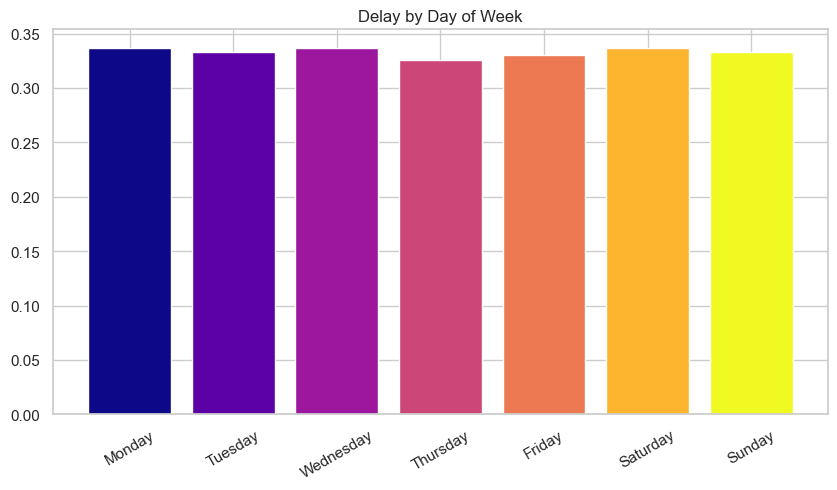

In [34]:
day_delay = df.groupby('Day of Departure')['IsDelayed'].mean().reindex(order)

plt.figure(figsize=(10,5))
colors = plt.cm.plasma(np.linspace(0,1,len(day_delay)))

plt.bar(day_delay.index, day_delay.values, color=colors)

plt.title("Delay by Day of Week")
plt.xticks(rotation=30)
plt.show()

Delay by Time of Day

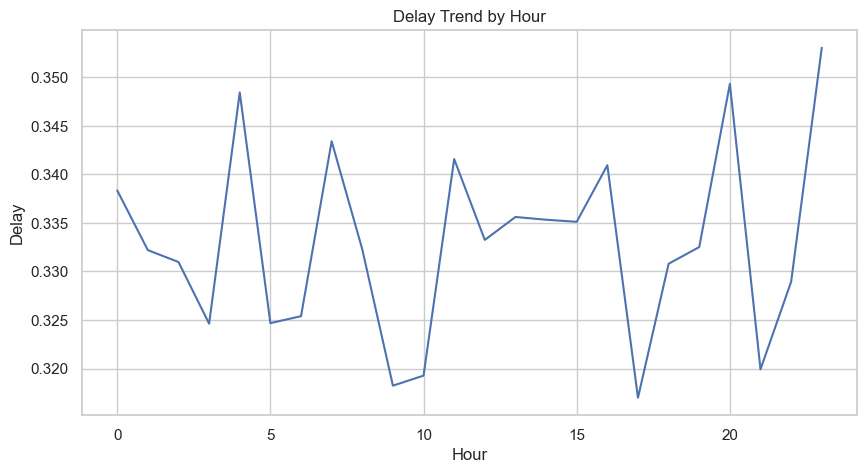

In [35]:
hour_delay = df.groupby('Hour')['IsDelayed'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=hour_delay.index, y=hour_delay.values)

plt.title("Delay Trend by Hour")
plt.xlabel("Hour")
plt.ylabel("Delay")
plt.show()

Boxplot

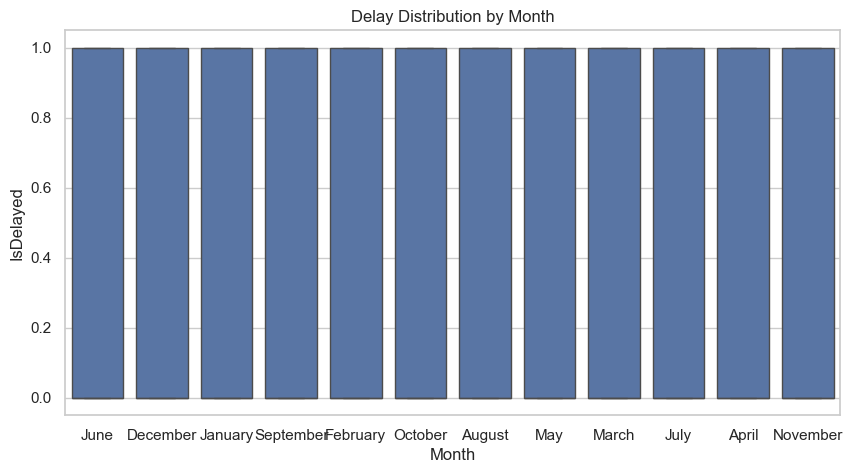

In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Month', y='IsDelayed', data=df)

plt.title("Delay Distribution by Month")
plt.show()

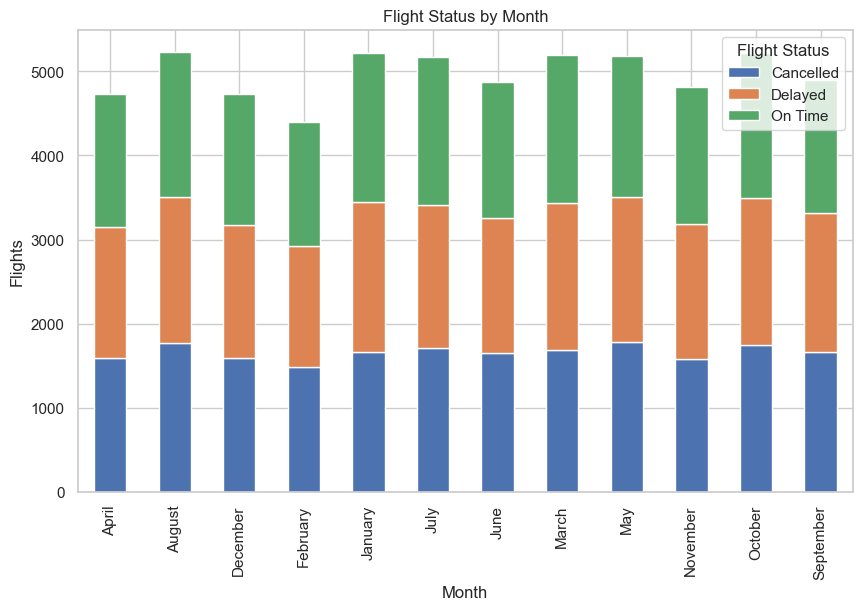

In [36]:
status_month = df.groupby(['Month','Flight Status']).size().unstack()

status_month.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Flight Status by Month")
plt.xlabel("Month")
plt.ylabel("Flights")
plt.show()

In [1]:
print("Milestone 2 Completed ✅")

Milestone 2 Completed ✅
